# UdaciSense: Optimized Object Recognition

## Notebook 4: Mobile Deployment

In this notebook, you'll prepare your optimized model for mobile deployment.
You'll explore how to convert your best optimized model to a cross-platform mobile-friendly format,
and evaluate the performance that UdaciSense mobile users can expect.

In [ ]:
!pip install tqdm

In [1]:
# Make sure that libraries are dynamically re-loaded if changed
%load_ext autoreload
%autoreload 2

In [2]:
# Import necessary libraries
import copy
import os
import json
import time
import numpy as np
import pandas as pd
import pprint
import random
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.quantization
from typing import Dict, Any, List, Tuple, Optional, Union, Callable
import warnings

from utils.data_loader import get_household_loaders, get_input_size, print_dataloader_stats, visualize_batch
from utils.model import MobileNetV3_Household, load_model, save_model, print_model_summary
from utils.visualization import (
    plot_model_comparison, plot_multiple_models_comparison, 
    create_model_summary_dashboard
)
from utils.compression import is_quantized
from utils.evaluation import evaluate_model_metrics, compare_models

/home/ubuntu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
# Ignore PyTorch deprecation warnings
import warnings
warnings.filterwarnings("ignore", category=torch.jit.TracerWarning)
warnings.filterwarnings("ignore", category=UserWarning)  # Optional: Ignore all user warnings

### Step 1: Set up the Environment

In [4]:
# Check if CUDA is available
devices = ["cpu"]
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    devices.extend([f"cuda:{i} ({torch.cuda.get_device_name(i)})" for i in range(num_devices)])
print(f"Devices available: {devices}")

Devices available: ['cpu', 'cuda:0 (NVIDIA A10)']


In [5]:
# Setup directories
os.makedirs("../models/mobile", exist_ok=True)
os.makedirs("../results/mobile", exist_ok=True)

In [6]:
# Set random seed for reproducibility
def set_deterministic_mode(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

set_deterministic_mode(42)
g = torch.Generator()
g.manual_seed(42)

### Step 2: Load the dataset

Extracting household classes from CIFAR100 for train set...
Extracting household classes from CIFAR100 for test set...
Input has size: (1, 3, 32, 32)
Datasets have these classes: 
  0: clock
  1: keyboard
  2: lamp
  3: telephone
  4: television
  5: bed
  6: chair
  7: couch
  8: table
  9: wardrobe

Information on train set
Statistics for train
 Size: 5000
 Samples per class:
  clock: 500
  keyboard: 500
  lamp: 500
  telephone: 500
  television: 500
  bed: 500
  chair: 500
  couch: 500
  table: 500
  wardrobe: 500
Examples of images from the train set


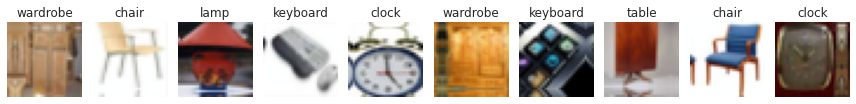


Information on test set
Statistics for test
 Size: 1000
 Samples per class:
  clock: 100
  keyboard: 100
  lamp: 100
  telephone: 100
  television: 100
  bed: 100
  chair: 100
  couch: 100
  table: 100
  wardrobe: 100
Examples of images from the test set


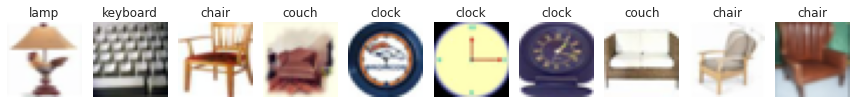

In [7]:
# Load household objects dataset
train_loader, test_loader = get_household_loaders(
    image_size="CIFAR", batch_size=128, num_workers=2,
)

# Get input_size
input_size = get_input_size("CIFAR")
print(f"Input has size: {input_size}")

# Get class names
class_names = train_loader.dataset.classes
print(f"Datasets have these classes: ")
for i in range(len(class_names)):
    print(f"  {i}: {class_names[i]}")

# Visualize some examples
for dataset_type, data_loader in [('train', train_loader), ('test', test_loader)]:
    print(f"\nInformation on {dataset_type} set")
    print_dataloader_stats(data_loader, dataset_type)
    print(f"Examples of images from the {dataset_type} set")
    visualize_batch(data_loader, num_images=10)

### Step 3. Load the optimized model and metrics

As we can see from 03_pipeline.ipynb implementation, we got the best results combining QAT model and Graph Optimization techniques.
However, we cannot load the final pipeline model straightaway due to the intricacies associated with QAT procedure. So, in order to get to the final pipeline model, we will have to take the following steps:
1) Load QAT model definition
2) Take the weights file from stage 1 of pipeline5 implemented
3) Run the _prepare_qat_model on model loaded in step 1 above
4) Convert the model in step 3 to int8 quantized. This can be accomplished by running _convert_qat_model_to_quantized on model obtained in step 3 above.
5) Load the model weights from step 2 above into int8 model obtained via step 4 above.
6) Run the graph optimization on loaded model from step 5.
##### And lo and behold, you got your QATGraphOptimized model back. Yippee!!

In [8]:
# TODO: Choose the experiment to load for
experiment_name = "QATGraphOpt"
optimized_model_path = "../models/in_training/quantization/epochs200_start/model.pth" #pipeline5stage1

In [14]:
from compression.in_training.quantization import train_model_qat, QuantizableMobileNetV3_Household_qat, _prepare_qat_model, _convert_qat_model_to_quantized

In [15]:
model = QuantizableMobileNetV3_Household_qat(dropout_rate=0.2, quantize=False)
model = _prepare_qat_model(model,  backend = "qnnpack")
model = _convert_qat_model_to_quantized(model)
f = torch.load(optimized_model_path)
model.load_state_dict(f)
#We got trained QAT model from pipeline5 stage 1. next we we graph optimization on this model

Hello moto
Fusing layers...


<All keys matched successfully>

In [16]:
model

QuantizableMobileNetV3_Household_qat(
  (model): QuantizableMobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): QuantizedConv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), scale=1.491334080696106, zero_point=140, padding=(1, 1))
        (1): Identity()
        (2): QuantizedHardswish()
      )
      (1): QuantizableInvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): QuantizedConvReLU2d(16, 16, kernel_size=(3, 3), stride=(2, 2), scale=0.2672690749168396, zero_point=0, padding=(1, 1), groups=16)
            (1): Identity()
            (2): Identity()
          )
          (1): QuantizableSqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): QuantizedConv2d(16, 8, kernel_size=(1, 1), stride=(1, 1), scale=0.00021873891819268465, zero_point=255)
            (fc2): QuantizedConv2d(8, 16, kernel_size=(1, 1), stride=(1, 1), scale=0.009732715785503387, zero_point=117)
      

In [17]:
input_size

(1, 3, 32, 32)

In [18]:
from compression.post_training.graph_optimization import optimize_model, verify_model_equivalence

In [19]:
def apply_graph_optimization(model=None, submod=False):
    ## TODO: EXPERIMENT WITH DIFFERENT  PARAMETERS
    ## We recommend testing testing with both optimization methods and device types
    ## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)
    optimization_method = "torch_fx"  # One of "torch_fx" or "torchscript"
    device = torch.device('cpu')  # Define with torch.device()

    # Optimize and evaluate model
    # Check optimization method is supported
    if optimization_method not in ["torchscript", "torch_fx"]:
        raise ValueError(f"Unsupported optimization method: {optimization_method}")
    
    # Define unique experiment name given main parameters
    experiment_name = f"post_training/graph_optimization/{optimization_method}_{device}"

    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying optimization with {optimization_method} as method")
    
    # Make a copy of the baseline model and move to specified device
    if not submod:
        orig_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(device)
    else:
        orig_model = model
        orig_model.to(device)

    input_shape=input_size
    # Apply graph optimization
    # TODO: IMPLEMENT THIS FUNCTION IN THE compression/ FOLDER 
    optimized_model = optimize_model(
        orig_model,
        optimization_method=optimization_method,
        input_shape=input_shape,
        device=device,
    )

    # Verify model equivalence
    is_equivalent = verify_model_equivalence(
        orig_model, 
        optimized_model, 
        input_shape=input_shape, 
        device=device
    )
          
    return optimized_model

In [20]:
optimized_model = apply_graph_optimization(model=model, submod=True)

Applying optimization with torch_fx as method
Original and optimized models produce equivalent outputs.


In [21]:
# Load the optimized model

# Load optimized model metrics
with open(f"../results/pipeline/{experiment_name}/pipeline_metrics.json", "r") as f:
    optimized_metrics = json.load(f)

print("\nOptimized Model Metrics:")
pprint.pp(optimized_metrics)


Optimized Model Metrics:
{'pipeline_name': 'QATGraphOpt',
 'steps': [{'step_name': 'in_training/quantization/epochs200_start',
            'metrics': {'accuracy': {'top1_acc': 87.6, 'top5_acc': 97.6},
                        'per_class_accuracy': {'clock': 92.0,
                                               'keyboard': 96.0,
                                               'lamp': 89.0,
                                               'telephone': 81.0,
                                               'television': 92.0,
                                               'bed': 84.0,
                                               'chair': 90.0,
                                               'couch': 79.0,
                                               'table': 79.0,
                                               'wardrobe': 95.0},
                        'timing': {'cpu': {'total_time_ms': 4068.0036544799805,
                                           'avg_time_ms': 40.680036544799805,
       

### Step 4. Convert optimized model for mobile

In [22]:
from torch.utils import mobile_optimizer

In [26]:
# TODO: Implement any required torch optimizations for deployment to mobile
# Review built-in functionalities for mobile (e.g., mobile_optimizer)
def convert_model_for_mobile(
    model: nn.Module,
    input_size: Tuple[int, ...] = (1, 3, 32, 32)
) -> Union[torch.jit.ScriptModule, str]:
    """
    Convert a PyTorch model to a mobile-friendly format.
    Currently focused on TorchScript but designed to be extensible.
    
    Args:
        model: PyTorch model to convert
        input_size: Shape of input tensor (possibly useful to create a dummy input)
    Returns:
        Converted model object
    """
    print("\nConverting model for mobile deployment...")
    example_input = torch.randn(input_size)
    traced_model = torch.jit.trace(model, example_input)
    optimized_model = mobile_optimizer.optimize_for_mobile(traced_model)
    return optimized_model

In [27]:
# Convert the model for mobile deployment

# Convert the model
mobile_model = convert_model_for_mobile(
    optimized_model, 
    input_size=input_size,
    #mobile_optimize=True,
)


Converting model for mobile deployment...


In [28]:
# Save the mobile model
# EXTRA: Test saving with lite interpreter instead - do you notice differences in performance?
mobile_model_path = f"../models/mobile/optimized_model_mobile.pt"
torch.jit.save(mobile_model, mobile_model_path)
print(f"Saved mobile-compatible model to: {mobile_model_path}")

Saved mobile-compatible model to: ../models/mobile/optimized_model_mobile.pt


### Step 5: Verify Mobile Model Performance

Before packaging for deployment, let's verify that your optimized model meets the requirements.

#### Model output consistency

In [29]:
# TODO: Implement checks to guarantee the same model outputs
# Once again, you can look at built-in PyTorch functionalities for inspiration
# Also consider which device to perform the operations on
def compare_model_outputs(
    model1: nn.Module,
    model2: nn.Module,
    input_tensor: torch.Tensor,
) -> bool:
    """
    Compare outputs of two models to verify consistency after conversion.
    Works with both regular PyTorch models and converted mobile models.
    
    Args:
        model1: First model
        model2: Second model
        input_tensor: Input tensor to test with
        
    Returns:
        True if outputs are consistent, False otherwise
    """
    model1.eval()
    model2.eval()
    with torch.no_grad():
        out_opt = model1(dummy_input)
    out_mob = model2(dummy_input)
    diff = torch.mean(torch.abs(out_opt)) - torch.mean(torch.abs(out_mob))
    print(diff)
    consistent = True if diff < 0.0001  else False
    return consistent


In [30]:
# Verify model output consistency
dummy_input = torch.randn(input_size)
output_consistency = compare_model_outputs(optimized_model, mobile_model, dummy_input)
print(f"Output consistency check: {'PASSED' if output_consistency else 'FAILED'}")

tensor(0.)
Output consistency check: PASSED


#### Model size

In [31]:
# Get the model size
# Consider if you want to return both or either model size in MB vs parameter count
def get_model_size(model_path: str) -> float:
    """
    Get the size of a model, whether it is optimized or not for mobile.
    
    Args:
        model_path: Filepath to the saved model
        
    Returns:
        Float number representing model size
    """
    size_bytes = os.path.getsize(model_path)
    return size_bytes/(1024**2)

optimized_size = get_model_size(optimized_model_path)
mobile_size = get_model_size(mobile_model_path)

print(f"Original model size: {optimized_size:.2f} MB")
print(f"Mobile model size: {mobile_size:.2f} MB")
print(f"\nSize change from optimized to mobile: {(mobile_size - optimized_size) / optimized_size * 100:.2f}%")

Original model size: 1.57 MB
Mobile model size: 1.53 MB

Size change from optimized to mobile: -2.59%


#### Evaluate models on test set

In [32]:
# TODO: Evaluate original optimized vs mobile model when it comes to accuracy and other performance metrics
# Feel free to choose one or more of the built-in evaluation and visualization methods, or create new ones!
metrics_mob = evaluate_model_metrics(
    mobile_model,
    test_loader,
    torch.device('cpu'),
    10,
)

Evaluating per-class accuracy: 100%|██████████| 8/8 [00:03<00:00,  2.62it/s]


In [33]:
metrics_mob

{'accuracy': {'top1_acc': 87.6, 'top5_acc': 97.6},
 'per_class_accuracy': {'class_0': 92.0,
  'class_1': 96.0,
  'class_2': 89.0,
  'class_3': 81.0,
  'class_4': 92.0,
  'class_5': 84.0,
  'class_6': 90.0,
  'class_7': 79.0,
  'class_8': 79.0,
  'class_9': 95.0},
 'timing': {'cpu': {'total_time_ms': 9284.001350402832,
   'avg_time_ms': 92.84001350402832,
   'fps': 10.771217735299123},
  'cuda': {}},
 'size': {'total_params': 401408,
  'trainable_params': 401408,
  'model_size_bytes': 1605633,
  'model_size_mb': 1.5312509536743164},
 'memory': {'peak_memory_mb': None, 'allocated_memory_mb': None}}

In [34]:
metrics_opt = evaluate_model_metrics(
    optimized_model,
    test_loader,
    torch.device('cpu'),
    10,
)

Evaluating per-class accuracy: 100%|██████████| 8/8 [00:03<00:00,  2.52it/s]


In [35]:
metrics_opt

{'accuracy': {'top1_acc': 87.6, 'top5_acc': 97.6},
 'per_class_accuracy': {'class_0': 92.0,
  'class_1': 96.0,
  'class_2': 89.0,
  'class_3': 81.0,
  'class_4': 92.0,
  'class_5': 84.0,
  'class_6': 90.0,
  'class_7': 79.0,
  'class_8': 79.0,
  'class_9': 95.0},
 'timing': {'cpu': {'total_time_ms': 8333.997011184692,
   'avg_time_ms': 83.33997011184692,
   'fps': 11.999044380000901},
  'cuda': {}},
 'size': {'total_params': 0,
  'trainable_params': 0,
  'model_size_bytes': 1644369,
  'model_size_mb': 1.568192481994629},
 'memory': {'peak_memory_mb': None, 'allocated_memory_mb': None}}

In [37]:
results_table = []
results_table.append({
    'Model': "QuantGraphOptModel",
    'Model Size (MB)': f"{metrics_opt.get('size').get('model_size_mb'):.2f}",
    'Inference Time (ms)': f"{metrics_opt.get('timing').get('cpu').get('avg_time_ms'):.2f}",
    'Accuracy (%)': f"{metrics_opt.get('accuracy').get('top1_acc'):.2f}",
        })
results_table.append({
    'Model': "QuantGraphOptMobileModel",
    'Model Size (MB)': f"{metrics_mob.get('size').get('model_size_mb'):.2f}",
    'Inference Time (ms)': f"{metrics_mob.get('timing').get('cpu').get('avg_time_ms'):.2f}",
    'Accuracy (%)': f"{metrics_mob.get('accuracy').get('top1_acc'):.2f}",
        })
results_table

[{'Model': 'QuantGraphOptModel',
  'Model Size (MB)': '1.57',
  'Inference Time (ms)': '83.34',
  'Accuracy (%)': '87.60'},
 {'Model': 'QuantGraphOptMobileModel',
  'Model Size (MB)': '1.53',
  'Inference Time (ms)': '92.84',
  'Accuracy (%)': '87.60'}]

In [38]:
comparison_df = pd.DataFrame(results_table)
print("\nComparison of Optimized and Mobile converted Model :\n")
display(comparison_df)


Comparison of Optimized and Mobile converted Model :



,Model,Model Size (MB),Inference Time (ms),Accuracy (%)
0,QuantGraphOptModel,1.57,83.34,87.60
1,QuantGraphOptMobileModel,1.53,92.84,87.60


#### Benchmark Mobile Performance

In this section, you should develop a strategy for benchmarking the model on actual mobile 
hardware. Since we can't easily test on ARM mobile devices in this environment, describe:

1. What tools and frameworks you would use for mobile benchmarking?
2. What specific metrics you would collect?
3. How you would set up a fair comparison between models?
4. What mobile-specific factors you would control for in your tests?

Write your benchmarking approach in the final report directly.

--------

**TODO: Collect results on mobile conversion and considerations for model deployment**

After converting your optimized model for mobile deployment, analyze how the model will perform in real-world mobile environments.

Consider these guiding questions:
- How did the mobile conversion affect the model's performance characteristics?
- What mobile-specific considerations impact this model's deployment?
- How would you rigorously benchmark performance across different devices?
- What challenges might arise in production deployment scenarios?
- What future improvements would you prioritize for model deployment?

Provide an analysis that demonstrates your understanding of mobile deployment considerations for the UdaciSense computer vision model.

## Optimized Model Mobile Deployment Analysis for UdaciSense Computer Vision Model

As observed in the table above, the converted mobile model maintains the accuracy level of the optimized model. The model size is slightly reduced from 1.57 MB (optimized model) to 1.53 MB (mobile-converted model). However, there is an increase of approximately 10 ms in inference time.

This increase is expected because the current evaluation environment is not the target mobile hardware for which the model is optimized. When deployed on actual mobile hardware with appropriate acceleration (such as mobile CPU optimizations, or hardware accelerators), the model is expected to achieve improved runtime performance.

To further evaluate performance, the model should be tested on representative target mobile devices. Benchmarking can be conducted across multiple devices to collect performance statistics such as mean inference time and standard deviation. Based on these measurements, acceptable performance thresholds can be defined to determine whether the model satisfies end-user latency and responsiveness requirements.

Additionally, testing should be performed under peak device utilization conditions (e.g., background apps running, CPU load, limited memory). These stress tests help identify the minimum hardware configuration required for the model to run reliably without degrading the user experience.


Several challenges may arise when deploying the model in real-world production environments:

Hardware Variability
Mobile devices vary widely in terms of CPU architecture, available memory, GPU/AI accelerators, and battery capacity. This variability can lead to differences in inference latency and energy consumption.

Operating System Fragmentation
Different mobile devices may run different OS versions and vendor-specific optimizations, which can affect runtime libraries and hardware acceleration support.

Resource Constraints
Mobile environments impose strict constraints on memory usage, storage, and power consumption, which may impact sustained inference performance.

Background Workloads
Concurrent applications and system services may compete for CPU and memory resources, introducing variability in model latency.

Battery and Thermal Conditions
Device thermal throttling or low battery modes may reduce CPU/GPU performance, affecting model responsiveness.


Several improvements can be prioritized to further enhance the deployment readiness and performance of the model on mobile platforms.

1. Device-Specific Performance Optimization

Since mobile devices vary significantly in terms of hardware capabilities, it is important to benchmark the model on a representative set of target devices. This would allow the collection of performance metrics such as inference latency, memory usage, and energy consumption. Based on these results, device-specific optimizations or configuration guidelines can be established to ensure consistent performance across different hardware platforms.

2. Hardware Acceleration Utilization

Future improvements should focus on leveraging mobile hardware accelerators/mobile GPUs where available. Utilizing these accelerators can significantly reduce inference latency and improve energy efficiency, which is critical for real-time mobile applications.

3. Robust Cross-Device Testing

Extensive testing across multiple device models, operating system versions, and runtime environments should be conducted to ensure stability and reliability in production. This includes evaluating performance under different system loads, background processes, and varying network conditions to simulate real-world usage scenarios.

4. Monitoring and Continuous Model Updates

In a production environment, it is important to establish mechanisms for performance monitoring and periodic model updates. Collecting anonymized usage statistics and performance metrics can help identify potential bottlenecks and guide future optimization efforts.

5. Energy Efficiency Evaluation

Mobile applications must balance performance with battery consumption. Future work should include measuring the energy impact of model inference and optimizing the deployment strategy to minimize power usage while maintaining acceptable latency.

> 🚀 **Next Step:** 
> Collect all your results and insights in `report.md`! 